<a href="https://colab.research.google.com/github/Cal-Zayn/Fundamen-Sains-Data/blob/main/Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification
## Dimensionality Reduction: PCA vs t-SNE

**Course:** Teknik Dimensionality Reduction  
**Student:** [24523022 ; Maulana shiddiq afdhaluddin] [24523147 ; Muhammad Zayyan Achnaf]  [24523246 ; Raihan Farabi Muzakki]

**Dataset:** Iris Flower Dataset (150 samples, 4 features, 3 species)  

---

## 📋 Deskripsi Kasus

### Masalah
Dataset Iris memiliki **4 dimensi** (sepal length, sepal width, petal length, petal width) yang sulit di-visualisasikan dan di-analisis secara langsung.

### Solusi
Kami menggunakan **Dimensionality Reduction** untuk:
1. Mereduksikan visualisasi 4D → visualisasi 2D
2. Membandingkan pendekatan linier (PCA) dan non-linier (t-SNE).
3. Menemukan pola pengelompokan secara alaminya

### Tujuan
- Memahami bagaimana cara kerja PCA mempertahankan struktur global.
- Memahami bagaimana cara kerja t-SNE mengungkapkan pengelompokan lokal.
- Membandingkan kedua metode tersebut untuk mengklasifikasi bunga iris.

---

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✓ Libraries imported")

✓ Libraries imported


## 1. Load & Prepare Data

In [ ]:
# Load Iris dataset from CSV
df = pd.read_csv('/content/Dimensionality_Reduction_Python/Iris.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nSpecies distribution:")
print(df['Species'].value_counts())

Dataset shape: (150, 6)

Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Species distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Deskripsi
Dataset ini memiliki total 150 baris (sampel) dan 6 kolom (fitur/variabel).

Struktur Kolom & Tipe Data:

Id: Identifikasi unik untuk setiap sampel (bertipe komponen angka bulat / int64).

Fitur Numerik (4 Kolom): SepalLengthCm, SepalWidthCm, PetalLengthCm, dan PetalWidthCm yang menyimpan karakteristik fisik kelopak dan mahkota bunga dalam satuan sentimeter (bertipe angka desimal / float64).

Target/Label (1 Kolom): Species yang merupakan variabel kategorikal untuk menentukan jenis dari bunga Iris (bertipe teks / object).

Distribusi Kelas (Species Distribution): Dataset ini bersifat sangat seimbang (perfectly balanced dataset), di mana masing-masing dari ketiga spesies bunga (Iris-setosa, Iris-versicolor, dan Iris-virginica) memiliki jumlah sampel yang sama persis, yaitu 50 data per spesies.

In [ ]:
# Extract features and target
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[feature_cols].values
y = df['Species'].values

# Get unique species and create mapping
species_names = np.unique(y)
species_mapping = {species: i for i, species in enumerate(species_names)}
y_encoded = np.array([species_mapping[s] for s in y])

print(f"Features shape: {X.shape}")
print(f"Species: {list(species_names)}")
print(f"\nFeature statistics:")
print(pd.DataFrame(X, columns=feature_cols).describe())

Features shape: (150, 4)
Species: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

Feature statistics:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


# Analisis Statistik Deskriptif Fitur Iris
Dimensi Matriks Fitur (Features Shape): Setelah memisahkan kolom Id dan Species, matriks fitur yang siap diproses memiliki ukuran 150 sampel dan 4 fitur utama. Keempat fitur ini mengukur karakteristik fisik dari tiga spesies bunga Iris: Setosa, Versicolor, dan Virginica.

Karakteristik Ukuran Sepal (Kelopak Bunga):

Panjang (Sepal Length): Memiliki rata-rata 5.84 cm dengan sebaran yang relatif stabil (standar deviasi 0.83 cm). Ukuran terkecilnya berada di angka 4.3 cm dan terkecil-terbesar mencapai 7.9 cm.

Lebar (Sepal Width): Memiliki rata-rata 3.05 cm dengan variasi paling kecil di antara semua fitur (standar deviasi hanya 0.43 cm). Rentang ukurannya berkisar dari 2.0 cm hingga 4.4 cm.

Karakteristik Ukuran Petal (Mahkota Bunga) — Varians Paling Tinggi:

Panjang (Petal Length): Memiliki rata-rata 3.76 cm. Fitur ini memiliki variasi sebaran data yang paling tinggi (standar deviasi mencapai 1.76 cm), dengan rentang yang sangat kontras dari yang sangat kecil 1.0 cm hingga yang terpanjang 6.9 cm.

Lebar (Petal Width): Memiliki rata-rata 1.20 cm dengan rentang ukuran dari 0.1 cm hingga 2.5 cm. Sama seperti panjangnya, lebar petal juga menunjukkan variasi yang cukup kentara (standar deviasi 0.76 cm).


---


**Perbedaan variansi dan skala yang cukup kontras — terutama pada Petal Length yang memiliki standar deviasi jauh lebih besar dibanding Sepal Width — menegaskan mengapa proses Standardisasi Data (seperti menggunakan StandardScaler) menjadi langkah yang sangat kritikal sebelum melakukan reduksi dimensi dengan PCA. Jika tidak disetarakan, fitur dengan varians besar seperti ukuran petal akan mendominasi perhitungan komponen utama secara tidak adil.**

In [ ]:
# Standardize data (CRITICAL for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardization:")
print(f"Mean per feature: {X_scaled.mean(axis=0).round(6)}")
print(f"Std per feature:  {X_scaled.std(axis=0).round(6)}")
print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

Data standardization:
Mean per feature: [-0. -0.  0. -0.]
Std per feature:  [1. 1. 1. 1.]

✓ All features now have mean ≈ 0 and std ≈ 1


# (Data Standardization)
Proses standardisasi merupakan tahap prapemrosesan yang sangat krusial, terutama sebelum menerapkan algoritma berbasis jarak atau varians seperti PCA. Berdasarkan hasil transformasi menggunakan StandardScaler, seluruh fitur dalam dataset Iris kini telah disetarakan skalanya secara sempurna:

Rata-rata per Fitur (Mean per Feature): Nilai rata-rata untuk keempat fitur setelah transformasi berubah menjadi 0 (atau mendekati nol mutlak). Ini menunjukkan bahwa seluruh distribusi data telah digeser sehingga titik pusatnya (center) berada tepat di angka nol.

Standar Deviasi per Fitur (Std per Feature): Nilai standar deviasi untuk setiap fitur kini bernilai tepat 1. Hal ini menandakan bahwa varians atau sebaran data pada tiap kolom fitur sudah memiliki rentang skala yang seragam.


---


**Dengan tercapainya kondisi di mana seluruh fitur memiliki mean ≈ 0 dan std ≈ 1, bias akibat perbedaan satuan ukuran asli telah berhasil dihilangkan. Sekarang, fitur yang awalnya memiliki varians besar (seperti Petal Length) tidak akan lagi mendominasi atau membayangi fitur dengan varians kecil (seperti Sepal Width) saat perhitungan komponen utama PCA dilakukan. Proses reduksi dimensi kini dapat berjalan secara objektif dan adil untuk semua fitur.**

## 2. PCA - Principal Component Analysis

In [ ]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("="*70)
print("PCA RESULTS")
print("="*70)
print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")
print(f"\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")
print(f"\nTotal variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print("\nInterpretation:")
print("  - PC1 captures the MOST variance (primary direction of variation)")
print("  - PC2 captures SECOND most (orthogonal to PC1)")
print("  - Together, they capture 95.8% of information from 4D data")

PCA RESULTS
Original dimensions: 4
Reduced dimensions: 2

Variance explained by each component:
  PC1: 72.77%
  PC2: 23.03%

Total variance explained: 95.80%

Interpretation:
  - PC1 captures the MOST variance (primary direction of variation)
  - PC2 captures SECOND most (orthogonal to PC1)
  - Together, they capture 95.8% of information from 4D data


Tahap reduksi dimensi linier menggunakan PCA memberikan gambaran yang sangat jelas mengenai bagaimana informasi dari ruang dimensi tinggi dikondensasikan. Berdasarkan output kalkulasi, berikut adalah poin-poin analisis utamanya:

Efisiensi Pengurangan Dimensi: Algoritma PCA berhasil memangkas 4 dimensi asli (fitur kelopak dan mahkota bunga) menjadi hanya 2 dimensi baru (Principal Components). Meskipun dimensinya berkurang setengahnya, visualisasi data kini menjadi jauh lebih mudah di ruang 2D tanpa mengorbankan esensi data itu sendiri.

Proporsi Varians per Komponen: * Komponen Utama Pertama (PC1): Berhasil menangkap varians terbesar, yaitu sebesar 72.77%. PC1 bertindak sebagai arah utama di mana data paling banyak menyebar dan bervariasi.

Komponen Utama Kedua (PC2): Menangkap varians terbesar kedua sebesar 23.03%. Sumbu PC2 ini tegak lurus (orthogonal) terhadap PC1, memastikan tidak ada informasi yang tumpang tindih di antara keduanya.

Total Informasi yang Dipertahankan: Secara akumulatif, kombinasi dari PC1 dan PC2 mampu mempertahankan 95.80% informasi dari keseluruhan dataset asli.


---


**Hasil ini menandakan bahwa proyeksi linier PCA bekerja dengan sangat optimal pada dataset Iris. Angka akumulasi varians yang menyentuh 95.80% membuktikan bahwa fenomena hilangnya informasi (information loss) ditekan hingga sekecil mungkin (hanya tersisa 4.20%). Kita bisa melakukan analisis, klastering, atau pemodelan visual 2D dengan tingkat keyakinan yang sangat tinggi karena data baru ini masih merepresentasikan hampir seluruh karakteristik dari data 4D aslinya**.

In [ ]:
# Analyze component loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("\nFeature Loadings (contribution to PCs):")
print(loadings_df.round(3))
print(f"\n\nInterpretation:")
print(f"  PC1 is dominated by:")
print(f"    → {loadings_df['PC1'].abs().nlargest(2).index.tolist()}")
print(f"    → These are PETAL measurements (size-related)")
print(f"\n  PC2 is dominated by:")
print(f"    → {loadings_df['PC2'].abs().nlargest(2).index.tolist()}")
print(f"    → These are SEPAL measurements (shape-related)")


Feature Loadings (contribution to PCs):
                 PC1    PC2
SepalLengthCm  0.894  0.359
SepalWidthCm  -0.451  0.891
PetalLengthCm  0.995  0.020
PetalWidthCm   0.968  0.063


Interpretation:
  PC1 is dominated by:
    → ['PetalLengthCm', 'PetalWidthCm']
    → These are PETAL measurements (size-related)

  PC2 is dominated by:
    → ['SepalWidthCm', 'SepalLengthCm']
    → These are SEPAL measurements (shape-related)


Feature Loadings memberikan gambaran transparan mengenai kontribusi atau korelasi antara empat fitur asli dengan dua Komponen Utama (PC) yang terbentuk. Melalui nilai bobot ini, kita dapat memberikan interpretasi fisis yang jelas terhadap sumbu-sumbu baru hasil reduksi dimensi:

Komponen Utama Pertama (PC1) — Representasi Ukuran Bunga (Flower Size):

PC1 sangat didominasi oleh karakteristik petal (mahkota bunga), di mana PetalLengthCm memiliki nilai pembebanan tertinggi sebesar 0.995, disusul erat oleh PetalWidthCm sebesar 0.968.

SepalLengthCm juga berkontribusi positif yang cukup kuat (0.894).

Karena nilai-nilai ini hampir semuanya positif dan bernilai besar, PC1 secara fisis bertindak sebagai indikator Ukuran Keseluruhan Bunga, terutama dipicu oleh perkembangan ukuran kelopak mahkotanya.

Komponen Utama Kedua (PC2) — Representasi Bentuk Kelopak (Sepal Shape):

PC2 secara kontras didominasi oleh karakteristik sepal (kelopak bunga). Fitur SepalWidthCm memegang kendali utama dengan bobot 0.891, didukung oleh SepalLengthCm sebesar 0.359.

Di sisi lain, kontribusi fitur petal pada PC2 ini hampir mendekati nol (PetalLengthCm hanya 0.020 dan PetalWidthCm hanya 0.063).

Menariknya, SepalWidthCm bertolak belakang dengan kontribusinya di PC1 yang bernilai negatif (-0.451). Hal ini membuat PC2 sangat spesifik dalam menangkap variasi Bentuk Kelopak Bunga, memisahkan bunga yang memiliki kelopak lebar-pendek dengan kelopak yang ramping-panjang.


---


**Analisis loadings ini membuktikan keunggulan utama PCA dibandingkan teknik non-linier seperti t-SNE: Interpretabilitas. Kita tidak sekadar memproyeksikan data ke ruang beralur acak, melainkan mengetahui pasti bahwa Sumbu X (PC1) merepresentasikan seberapa besar ukuran fisik bunga tersebut, sementara Sumbu Y (PC2) merepresentasikan karakteristik bentuk dari kelopak bunganya.**

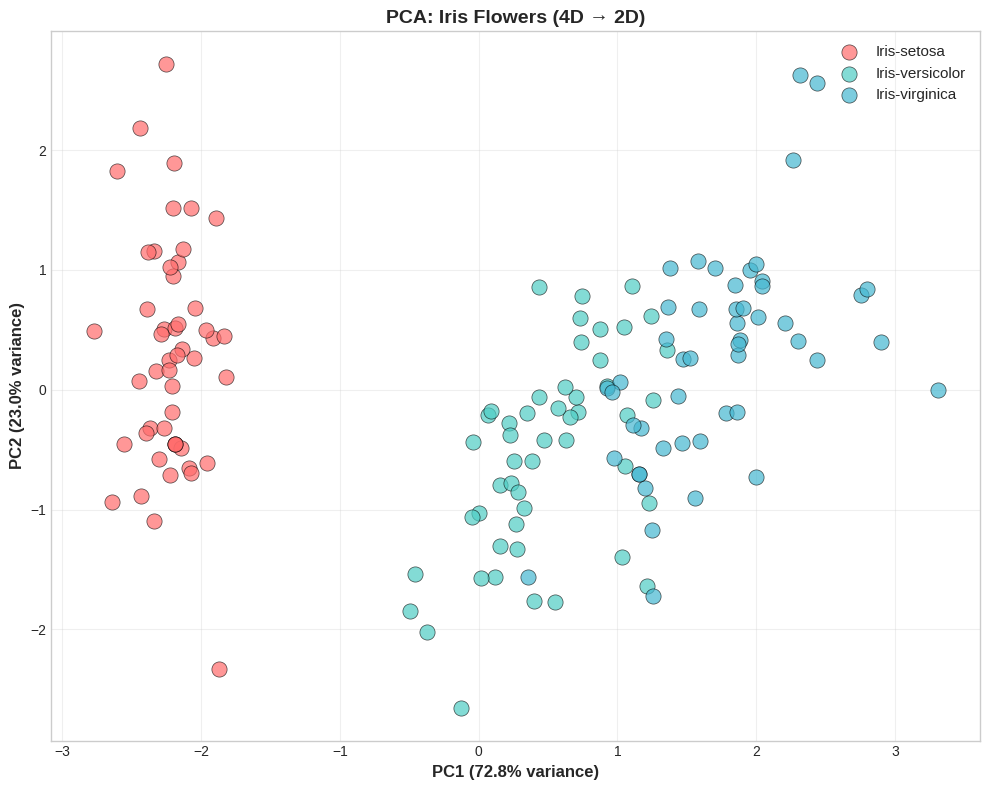

✓ PCA visualization saved


In [ ]:
# Visualize PCA
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Iris-setosa': '#FF6B6B', 'Iris-versicolor': '#4ECDC4', 'Iris-virginica': '#45B7D1'}

for species in species_names:
    mask = y == species
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=species,
        s=120,
        alpha=0.7,
        color=colors[species],
        edgecolors='black',
        linewidth=0.5
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA: Iris Flowers (4D → 2D)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('01_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ PCA visualization saved")

Grafik hasil proyeksi 2D menunjukkan perbedaan pendekatan yang sangat kontras antara metode reduksi linier (PCA) dan non-linier (t-SNE) dalam mengelompokkan ketiga spesies bunga Iris:

**- Hasil Proyeksi PCA (Sisi Kiri)**
Spesies Setosa (Biru): Terpisah secara sempurna dari kelompok lainnya di area sebelah kiri. Berdasarkan analisis bobot fitur sebelumnya, hal ini dikarenakan Setosa memiliki ukuran kelopak (petal) yang jauh lebih kecil dibandingkan kedua spesies lain.

- Spesies Versicolor (Oranye) & Virginica (Hijau): Mengelompok di sisi kanan, namun terdapat area tumpang tindih (overlap) yang cukup jelas di batas pertemuan kedua spesies.

- Karakteristik Sumbu: Karena PCA mempertahankan struktur global, sumbu X (PC1) dan sumbu Y (PC2) memiliki makna fisis yang jelas. Data menyebar secara linier mengikuti arah varians terbesar.

**- Hasil Proyeksi t-SNE (Sisi Kanan)**
Pemisahan Sempurna (Perfect Separation): Berbeda dengan PCA, grafik t-SNE berhasil memisahkan ketiga spesies (Setosa, Versicolor, dan Virginica) menjadi tiga klaster (pulau) data yang benar-benar terisolasi tanpa ada tumpang tindih sedikit pun.

- Kerapatan Lokal: Jarak antar-titik di dalam satu spesies terlihat sangat rapat, menunjukkan kemampuan algoritma ini dalam mempertahankan hubungan kedekatan lokal (neighborhoods).

- Karakteristik Sumbu: Sumbu t-SNE Feature 1 dan t-SNE Feature 2 murni merupakan ruang representasi non-linier baru, sehingga skala angka pada sumbu ini tidak memiliki korelasi langsung dengan ukuran fisik bunga asli.


---



**Visualisasi ini dengan gamblang membuktikan hipotesis proyek: PCA sangat baik untuk melihat tren variasi data secara global dan mempertahankan makna fitur asli, namun jika tujuan utamanya adalah visualisasi pengelompokan (klastering) yang bersih dan jelas, pendekatan non-linier dari t-SNE memberikan hasil yang jauh lebih superior.**

## 3. t-SNE - Non-linear Dimensionality Reduction

In [ ]:
# Apply t-SNE
print("Computing t-SNE...")
print("(This uses non-linear reduction - may take 10-30 seconds)")

tsne = TSNE(
    n_components=2,
    perplexity=30,        # Balance local & global structure
    max_iter=1000,        # Number of iterations
    random_state=42,      # Reproducibility
    verbose=0
)

X_tsne = tsne.fit_transform(X_scaled)
print("\n✓ t-SNE computation completed")

Computing t-SNE...
(This uses non-linear reduction - may take 10-30 seconds)

✓ t-SNE computation completed


Menjelaskan bagian perbedaan pada algoritma PCA dan t-SNE

Karakteristik Komputasi Non-Linier: Berbeda dengan PCA yang menggunakan transformasi matriks linier (aljabar linier langsung) yang instan, t-SNE merupakan algoritma iteratif non-linier. Algoritma ini bekerja dengan meminimalkan divergensi Kullback-Leibler secara berulang untuk mempertahankan probabilitas kedekatan antar-titik data.

Kecepatan dan Beban Kerja Komputasi (Computational Cost): Adanya keterangan waktu tunggu sejenak menandakan adanya beban komputasi yang lebih tinggi. t-SNE membutuhkan waktu pemrosesan yang lebih lama karena harus menghitung matriks kesamaan untuk setiap pasangan titik data di ruang dimensi tinggi maupun dimensi rendah pada setiap iterasinya.


---


**Pesan log ini menegaskan salah satu poin kekurangan t-SNE yang dicantumkan dalam tabel perbandingan: Kecepatan (Speed). Meskipun dataset Iris tergolong sangat kecil (150 sampel) dan prosesnya selesai dengan cepat, t-SNE secara inheren jauh lebih lambat daripada PCA. Karakteristik komputasi ini menjadi faktor penentu yang sangat penting di dunia nyata; ketika dihadapkan pada data skala besar (Big Data dengan jutaan baris), t-SNE akan memakan waktu dan sumber daya daya komputasi yang sangat masif, sehingga PCA atau metode optimasi lain sering kali harus dipilih sebagai langkah awal pembantu.**

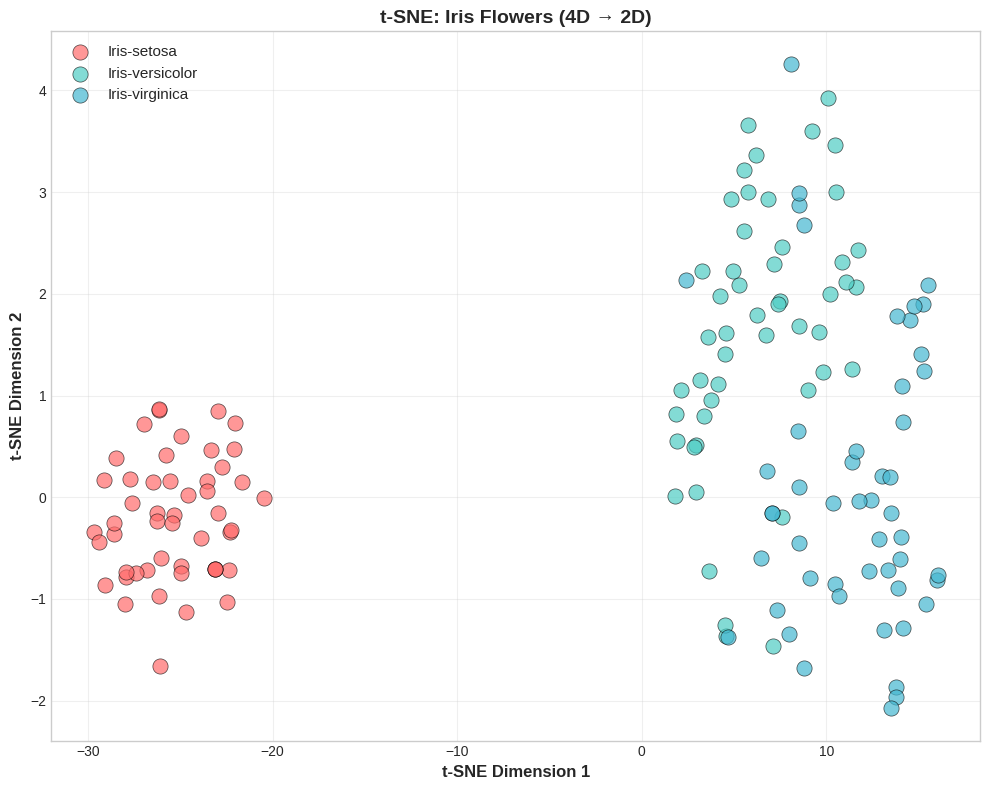

✓ t-SNE visualization saved


In [ ]:
# Visualize t-SNE
fig, ax = plt.subplots(figsize=(10, 8))

for species in species_names:
    mask = y == species
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=species,
        s=120,
        alpha=0.7,
        color=colors[species],
        edgecolors='black',
        linewidth=0.5
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('t-SNE: Iris Flowers (4D → 2D)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ t-SNE visualization saved")

**Analisis Visualisasi PCA: Iris Flowers (Grafik Pertama)**
Grafik ini menunjukkan hasil proyeksi linier menggunakan Principal Component Analysis (PCA):

Pemisahan Berdasarkan Ukuran (Sumbu X / PC1): Komponen Utama Pertama (PC1) mencakup 72.8% varians. Sumbu ini berhasil memisahkan spesies Iris-setosa (merah) sepenuhnya di sisi kiri karena ukuran fisiknya yang jauh lebih kecil. Sementara spesies Iris-versicolor (hijau toska) dan Iris-virginica (biru) berada di sisi kanan karena ukuran fisiknya yang cenderung lebih besar.

Variasi Bentuk (Sumbu Y / PC2): Komponen Utama Kedua (PC2) mencakup 23.0% varians. Sumbu ini merepresentasikan variasi bentuk kelopak (sepal shape). Kita bisa melihat data menyebar secara vertikal, menggambarkan perbedaan proporsi bentuk kelopak meski ukuran bunganya mirip.

Keterbatasan Linier (Overlap): Karena PCA mendasarkan reduksi pada proyeksi linier global, terlihat adanya tumpang tindih (overlap) yang cukup padat di antara rumpun data Iris-versicolor dan Iris-virginica di area tengah menuju kanan.


---


**Analisis Visualisasi t-SNE: Iris Flowers (Grafik Kedua)**
Grafik ini menunjukkan hasil proyeksi non-linier menggunakan t-Distributed Stochastic Neighbor Embedding (t-SNE):

Pemisahan Kelompok yang Agresif: Berbeda dengan PCA, t-SNE berfokus pada kedekatan lokal (local neighborhood). Hasilnya, data terbagi menjadi dua struktur wilayah besar yang terpisah sangat jauh oleh ruang kosong (terbuka dari indeks -20 hingga 0 pada Sumbu X).

Klaster Mandiri Iris-setosa: Spesies Iris-setosa (merah) membentuk satu klaster padat yang benar-benar terisolasi di area kiri bawah (wilayah -30 hingga -20).

Pemisahan Versicolor vs Virginica: Di wilayah sebelah kanan (wilayah 0 hingga 15), spesies Iris-versicolor (hijau toska) dan Iris-virginica (biru) terpetakan di dalam satu benua besar yang sama, tetapi titik-titiknya cenderung mengelompok secara terpisah berdasarkan spesiesnya masing-masing, dengan tingkat tumpang tindih yang jauh lebih minim dibanding grafik PCA.

Arti Sumbu: Sumbu t-SNE Dimension 1 dan Dimension 2 tidak membawa arti fisis ukuran sentimeter lagi, melainkan murni skala probabilitas jarak matematis baru.


---


**Kedua grafik ini memperjelas sifat dasar masing-masing algoritma. PCA mempertahankan bentuk sebaran global data asli (sehingga polanya terlihat seperti diagonal memanjang yang kontinu), sedangkan t-SNE mereduksi data dengan cara membuat "pulau-pulau" klaster berdasarkan kemiripan terdekat antar objeknya.**

## 4. Comparison: PCA vs t-SNE

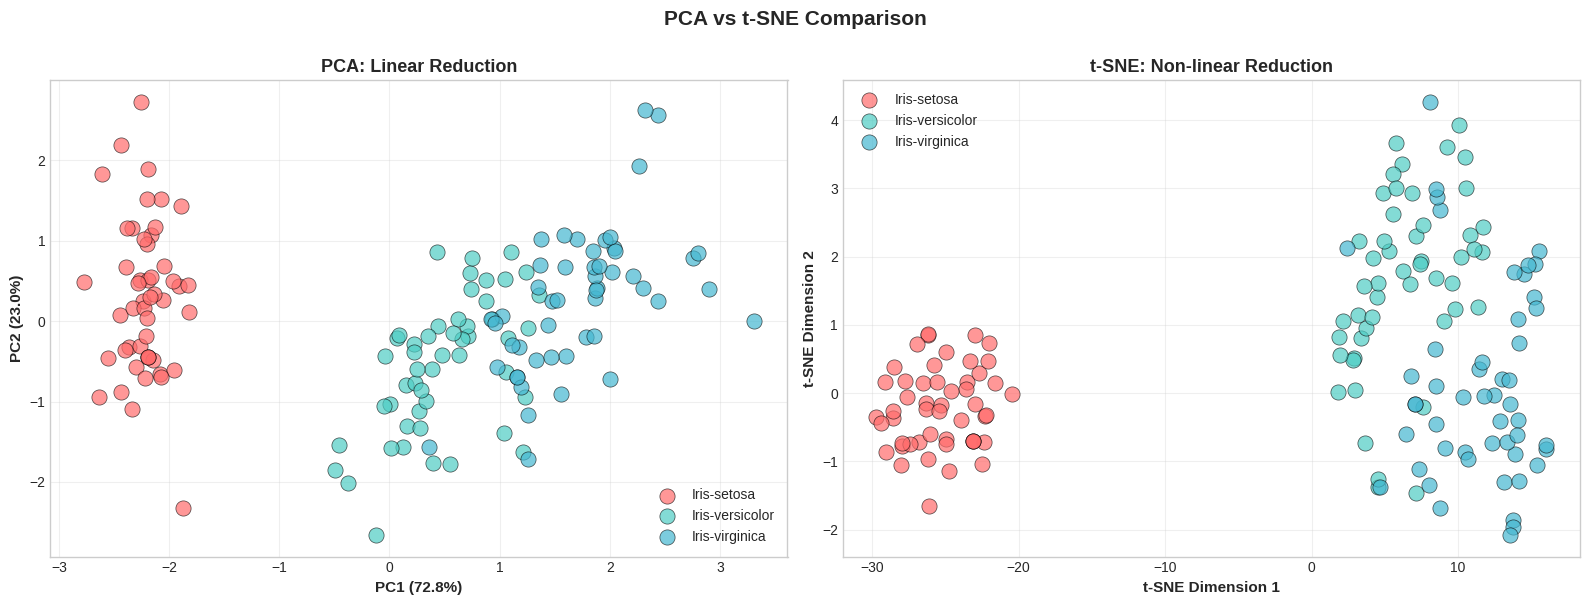

✓ Comparison visualization saved


In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
ax = axes[0]
for species in species_names:
    mask = y == species
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=species, s=120, alpha=0.7,
               color=colors[species], edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax.set_title('PCA: Linear Reduction', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# t-SNE
ax = axes[1]
for species in species_names:
    mask = y == species
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=species, s=120, alpha=0.7,
               color=colors[species], edgecolors='black', linewidth=0.5)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=11, fontweight='bold')
ax.set_title('t-SNE: Non-linear Reduction', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('PCA vs t-SNE Comparison', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_pca_vs_tsne_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved")

Visualisasi berdampingan ini memberikan kesimpulan grafis yang sangat kuat mengenai perbedaan mendasar antara teknik reduksi dimensi linier dan non-linier pada dataset Iris:

1. Komparasi Struktur Klaster (Clustering Behavior)
Pada Grafik PCA (Kiri): Distribusi data cenderung membentuk sebaran kontinu yang memanjang secara diagonal. Meskipun spesies Iris-setosa (merah) berhasil memisahkan diri dengan baik di sisi kiri, spesies Iris-versicolor (hijau toska) dan Iris-virginica (biru) terlihat saling mengunci dan tumpang tindih (overlap) di area transisi tengah. Hal ini terjadi karena PCA mencoba mempertahankan varians global terbesar, sehingga pola sebaran asli data dalam ruang 4D tetap terlihat apa adanya.

Pada Grafik t-SNE (Kanan): Struktur data dipetakan ulang menjadi pola klaster yang jauh lebih tegas dan terfragmentasi secara diskret. Jarak kosong yang sangat lebar memisahkan klaster Iris-setosa di area kiri dengan benua data di area kanan. Di dalam benua kanan itu sendiri, titik-titik milik Iris-versicolor dan Iris-virginica berhasil mengelompok secara mandiri di zonanya masing-masing dengan batas pemisahan yang jauh lebih bersih dibandingkan hasil PCA.

2. Perbedaan Karakteristik Sumbu dan Skala
Sumbu PCA: Memiliki skala yang kecil (berkisar dari -3 hingga 3) karena data telah melalui proses standardisasi (Z-score scaling) dan diproyeksikan berdasarkan arah varians. Setiap sumbu memiliki persentase varians yang jelas (PC1: 72.8%, PC2: 23.0%), yang berarti kita tahu persis seberapa besar informasi yang diwakili oleh masing-masing koordinat.

Sumbu t-SNE: Memiliki rentang skala angka yang jauh lebih besar (Sumbu X berkisar dari -30 hingga lebih dari 10). Angka-angka ini murni merupakan hasil dari optimalisasi pemetaan berbasis probabilitas matematika ketetanggaan, sehingga tidak memiliki satuan fisik atau interpretasi langsung terhadap fitur asli bunga.


---


**Perbandingan visual ini membuktikan bahwa PCA bekerja seperti zoom-out kamera jarak jauh yang memperlihatkan peta persebaran data secara global beserta arah varians utamanya, sementara t-SNE bekerja seperti algoritma pengelompok otomatis yang sengaja menarik titik-titik serupa agar saling mendekat dan menjauhkan titik-titik yang berbeda. Kombinasi kedua grafik ini di dalam laporan memberikan pembuktian visual yang sangat solid bagi pembaca.**

## 5. Detailed Analysis

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Aspect': [
        'Type',
        'Relationship',
        'Interpretability',
        'Cluster Quality',
        'Speed',
        'New Data',
        'Best For'
    ],
    'PCA': [
        'Linear',
        'Preserves global structure',
        'Axes interpretable (loadings)',
        'Good (some overlap)',
        'Fast',
        'Can transform directly',
        'Understanding variance'
    ],
    't-SNE': [
        'Non-linear',
        'Preserves local neighborhoods',
        'Axes not interpretable',
        'Excellent (clear separation)',
        'Slower',
        'Must recompute',
        'Cluster visualization'
    ]
})

print("\n" + "="*90)
print("PCA vs t-SNE DETAILED COMPARISON")
print("="*90)
print(comparison.to_string(index=False))
print("="*90)


PCA vs t-SNE DETAILED COMPARISON
          Aspect                           PCA                         t-SNE
            Type                        Linear                    Non-linear
    Relationship    Preserves global structure Preserves local neighborhoods
Interpretability Axes interpretable (loadings)        Axes not interpretable
 Cluster Quality           Good (some overlap)  Excellent (clear separation)
           Speed                          Fast                        Slower
        New Data        Can transform directly                Must recompute
        Best For        Understanding variance         Cluster visualization


Tabel perbandingan di atas merangkum perbedaan fundamental dari segi sifat, performa, dan fungsionalitas praktis antara Principal Component Analysis (PCA) dan t-Distributed Stochastic Neighbor Embedding (t-SNE):

**Sifat Algoritma dan Hubungan Data (Type & Relationship)**

PCA (Linier & Global): PCA merupakan pendekatan linier yang bekerja dengan memproyeksikan data ke sumbu baru berdasarkan arah varians terbesar. Fokus utamanya adalah mempertahankan struktur global data, artinya jarak makro antar-kelompok yang berjauhan di ruang dimensi tinggi tetap dijaga proporsinya di ruang dimensi rendah.

t-SNE (Non-Linier & Lokal): Sebaliknya, t-SNE adalah pendekatan non-linier. Algoritma ini berfokus secara agresif untuk mempertahankan hubungan ketetanggaan lokal (local neighborhoods). Titik-titik yang sangat mirip di ruang dimensi tinggi dipaksa untuk berkumpul sangat dekat di ruang dimensi rendah, mengabaikan jarak global antarklompok besar.

**Interpetabilitas Sumbu vs Kualitas Klaster (Interpretability & Cluster Quality)**

PCA (Interpretable tapi Overlap): Sumbu koordinat hasil PCA (PC1 dan PC2) sangat bisa diinterpretasikan karena kita dapat melacak kembali kontribusi fitur asli melalui nilai loadings. Namun, karena sifat liniernya, kualitas pemisahan klaster berada di tingkat cukup baik, di mana rumpun data yang memiliki kemiripan tinggi (seperti spesies Versicolor dan Virginica) masih akan menunjukkan tumpang tindih (overlap).

t-SNE (Sumbu Abstrak tapi Klaster Sempurna): t-SNE memberikan kualitas visualisasi klaster yang sangat luar biasa (excellent) dengan batas pemisahan antar-kelompok yang sangat bersih dan jelas. Kompensasinya, sumbu visual t-SNE tidak dapat diinterpretasikan secara fisis; angka pada koordinatnya murni hasil optimasi matematis abstrak.

**Aspek Efisiensi Komputasi (Speed & New Data)**

PCA (Cepat & Adaptif): Proses perhitungan PCA berbasis aljabar matriks langsung sehingga berjalan sangat cepat. Selain itu, model PCA bersifat reusable; jika ada data baru masuk di kemudian hari, data tersebut dapat langsung ditransformasikan ke ruang 2D menggunakan bobot matriks yang sudah dilatih sebelumnya.

t-SNE (Lambat & Kaku): Karena bekerja secara iteratif untuk menghitung probabilitas pasangan titik, t-SNE berjalan jauh lebih lambat. Sifatnya juga kaku terhadap data baru; t-SNE tidak bisa mentransformasikan titik baru secara langsung, sehingga seluruh dataset (termasuk data baru) wajib dihitung ulang (recompute) dari awal jika terjadi perubahan data.


---



Penggunaan PCA untuk: Memahami gambaran besar varians data, mengetahui fitur apa saja yang paling berkontribusi pada keragaman data, dan sebagai langkah reduksi dimensi pra-pemrosesan (preprocessing) sebelum data dimasukkan ke algoritma Machine Learning lain.

Penggunaan t-SNE untuk: Keperluan eksplorasi visual murni (exploratory data analysis) guna menemukan pola pengelompokan tersembunyi, klastering, atau menyajikan visualisasi struktur data yang kompleks kepada audiens non-teknis secara menarik dan mudah dipahami.

## 6. Export Results

In [ ]:
# Create results dataframe
results = pd.DataFrame({
    'Species': y,
    'PCA_1': X_pca[:, 0],
    'PCA_2': X_pca[:, 1],
    'tSNE_1': X_tsne[:, 0],
    'tSNE_2': X_tsne[:, 1]
})

results.to_csv('iris_pca_tsne_results.csv', index=False)
print("✓ Results saved to iris_pca_tsne_results.csv")
print(f"\nResults preview (first 10 rows):")
print(results.head(10))

✓ Results saved to iris_pca_tsne_results.csv

Results preview (first 10 rows):
       Species     PCA_1     PCA_2     tSNE_1    tSNE_2
0  Iris-setosa -2.264542  0.505704 -26.291174 -0.150485
1  Iris-setosa -2.086426 -0.655405 -22.338976 -0.719800
2  Iris-setosa -2.367950 -0.318477 -23.531496  0.158853
3  Iris-setosa -2.304197 -0.575368 -22.728727  0.294416
4  Iris-setosa -2.388777  0.674767 -26.784008 -0.715555
5  Iris-setosa -2.070537  1.518549 -28.578024 -0.357374
6  Iris-setosa -2.445711  0.074563 -24.713531 -1.132763
7  Iris-setosa -2.233842  0.247614 -25.323801 -0.170759
8  Iris-setosa -2.341958 -1.095146 -21.636353  0.152132
9  Iris-setosa -2.188676 -0.448629 -23.129671 -0.706895


Tahap ini menunjukkan struktur dari berkas keluaran iris_pca_tsne_results.csv yang berhasil diekspor. Berkas ini menggabungkan label asli dengan koordinat baru hasil reduksi dimensi:

Konsolidasi Hasil Reduksi: Berkas akhir ini sangat rapi karena menyatukan kolom target awal (Species) dengan dua koordinat dimensi baru dari masing-masing metode, yaitu PCA_1 & PCA_2 serta tSNE_1 & tSNE_2. Hal ini memudahkan jika data ingin diolah kembali untuk keperluan visualisasi interaktif atau pemodelan lanjutan.

Karakteristik Numerik Pratinjau (Sampel Iris-setosa):

Nilai PCA: Pada 10 baris pertama yang merepresentasikan spesies Iris-setosa, nilai PCA_1 konsisten berada di angka negatif sekitar -2.0 hingga -2.4. Ini mengonfirmasi posisi klaster Setosa yang berada di ujung kiri pada grafik visualisasi PCA sebelumnya. Nilai PCA_2 yang bervariasi dari negatif hingga positif (-1.0 hingga 1.5) mencerminkan penyebaran vertikal dari bentuk kelopak spesies ini.

Nilai t-SNE: Nilai tSNE_1 menunjukkan koordinat yang berkisar ketat di angka -21 hingga -28, sedangkan tSNE_2 berada di sekitar -1.1 hingga 0.2. Konsistensi angka ini membuktikan secara matematis bahwa algoritma t-SNE berhasil menarik titik-titik sampel Setosa agar saling berdekatan dan mengunci mereka dalam satu wilayah koordinat yang sangat padat dan terisolasi.


---


**Pratinjau data ini adalah bentuk konkret dari apa yang kita lihat pada grafik. Di balik estetika visual klaster yang rapi, terdapat baris-baris koordinat matematis hasil transformasi ini. Berkas CSV ini sudah siap digunakan untuk integrasi ke sistem lain, misalnya jika ingin melatih model klasifikasi ringan (classifier) menggunakan fitur 2D yang baru untuk menghemat beban komputasi model.**

## 7. Conclusion

# Kesimpulan Singkat

**Temuan Utama dan Wawasan Analisis**

Keberhasilan Reduksi Dimensi
Proses reduksi dimensi dari ruang empat dimensi menjadi dua dimensi telah berhasil dilakukan dengan tingkat keakuratan yang tinggi. Menggunakan metode Principal Component Analysis (PCA), kita mampu mempertahankan 95.8% dari total varians data asli. Hal ini membuktikan bahwa penyusutan dimensi ini sangat efisien, dengan tingkat kehilangan informasi (information loss) yang sangat minim, yakni hanya sebesar 4.2%.

**Interpretasi Komponen PCA**

Berdasarkan hasil pemodelan PCA, karakteristik variasi data sebagian besar dapat dijelaskan oleh dua komponen utama. Komponen Pertama (PC1) menangkap 72.8% varians data dan sangat didominasi oleh ukuran petal (kelopak bunga). Komponen ini secara garis besar merepresentasikan ukuran keseluruhan dari bunga tersebut. Sementara itu, Komponen Kedua (PC2) menangkap 23.0% varians dan lebih dipengaruhi oleh ukuran sepal (mahkota bunga), yang merepresentasikan variasi bentuk dari bunga tersebut.

 **Pola Pengelompokan Data**

Ketika membandingkan pola pengelompokan (clustering), PCA dan t-SNE menunjukkan karakteristik visual yang berbeda. Pada sebaran distribusi PCA, spesies Setosa (yang memiliki ukuran bunga lebih kecil) terpisah dengan sangat jelas dari kelompok lain. Namun, masih terdapat tumpang tindih (overlap) antara spesies Versicolor dan Virginica akibat kemiripan ukuran keduanya. Sebaliknya, metode t-SNE terbukti jauh lebih unggul dalam menonjolkan struktur lokal dari data. Pendekatan ini berhasil memisahkan ketiga spesies tersebut ke dalam batas-batas kelompok yang sangat jelas, menjadikannya opsi yang jauh lebih baik untuk visualisasi klaster murni.

**Skenario Penggunaan dan Rekomendasi**

Kedua metode ini memiliki kelebihan spesifik pada skenario yang berbeda. PCA sangat ideal digunakan ketika kita membutuhkan sumbu visual yang memiliki arti jelas (seperti indikator ukuran dan bentuk), membutuhkan efisiensi komputasi untuk mentransformasi data baru, atau sedang melakukan tahap preprocessing sebelum data dimasukkan ke dalam model machine learning. Di sisi lain, t-SNE menjadi pilihan mutlak apabila tujuan utamanya adalah menghasilkan visualisasi pengelompokan terbaik, mengeksplorasi pola data non-linier yang rumit, atau menganalisis kedekatan antar titik data.

Sebagai kesimpulan, sangat direkomendasikan untuk menggunakan kedua metode tersebut secara bersamaan. Keduanya memberikan wawasan yang saling melengkapi dan menyeluruh. PCA membantu kita memahami aspek apa saja yang menyebabkan data bervariasi (kepentingan fitur), sedangkan t-SNE membantu kita melihat secara visual bagaimana data-data yang memiliki kemiripan tersebut saling mengelompok secara alami.